#  PROJET FINAL — VISUALISATION DES DONNÉES UNIVERSITAIRES

## CONTEXTE

Ce projet est la suite directe du projet d'analyse réalisé avec **Pandas**.

Les analyses de base ont déjà été réalisées dans le projet Pandas : nettoyage, valeurs manquantes, jointures, calculs, moyennes, taux de réussite, analyses par filière/matière, présence, absences, retards, corrélations et classements.

**Ne refais donc pas tout le projet Pandas.**

Récupère le DataFrame final propre et utilise-le comme point de départ. L'objectif est maintenant de maîtriser **Matplotlib et Seaborn** pour transformer les résultats en représentations graphiques claires et les interpréter.

---

# PARTIE 0 — RÉCUPÉRATION DU DATAFRAME FINAL

### Travail
- Importer Pandas, Matplotlib et Seaborn.
- Charger le DataFrame final du projet Pandas.
- Afficher quelques lignes.
- Vérifier dimensions, colonnes et types.
- Vérifier les variables nécessaires aux graphiques.

### Questions
1. Combien de lignes possède le DataFrame ?
2. Combien de colonnes ?
3. Quelles variables seront utilisées ?
4. Quelles variables sont numériques ?
5. Quelles sont catégorielles ?
6. Existe-t-il encore des valeurs manquantes pouvant influencer les graphiques ?
7. Les données sont-elles prêtes pour la visualisation ?

---


In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:

data = pd.read_csv("../projet_pandas_universitaire/Données_collectés/Classement_General/Classement_Generale_par_ordre_de_merite.csv")
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent


In [3]:
data.tail()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
795,ETU1138,Lawson,Kodjo,17,F,Génie Civil,L1,5.59,Tres faible
796,ETU1357,Kouassi,Eyram,22,M,Génie Électrique,L1,5.21,Tres faible
797,ETU1746,Tchalla,Sena,21,M,IA & Big Data,L2,5.16,Tres faible
798,ETU1379,Adjei,Koffi,24,F,Génie Civil,L2,5.12,Tres faible
799,ETU1541,Mensah,Ama,25,M,Informatique & Systèmes,L3,4.33,Tres faible


In [4]:
# Les donnes sont deja pretes pour la visualisation


# PARTIE 1 — RÉPARTITION PAR FILIÈRE

### Graphiques
- Barplot des effectifs.
- Représentation des proportions.

### Questions
1. Quelle filière possède le plus d'étudiants ?
2. Quelle possède le moins d'étudiants ?
3. Les effectifs sont-ils équilibrés ?
4. Quelle proportion représente chaque filière ?
5. Le graphique confirme-t-il l'analyse Pandas ?
6. Quelle représentation est la plus lisible ?
7. Pourquoi ?

---

#### 1 et 2) Identification de la filiere posserdant le plus d'etudiant 

In [5]:
df = data["filiere"].value_counts()
df= df.reset_index()
df

,filiere,count
0,Informatique & Systèmes,200
1,IA & Big Data,189
2,Génie Électrique,150
3,Génie Civil,131
4,Logistique & Transport,130


C:\Users\dc\AppData\Local\Temp\ipykernel_33216\4256797949.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


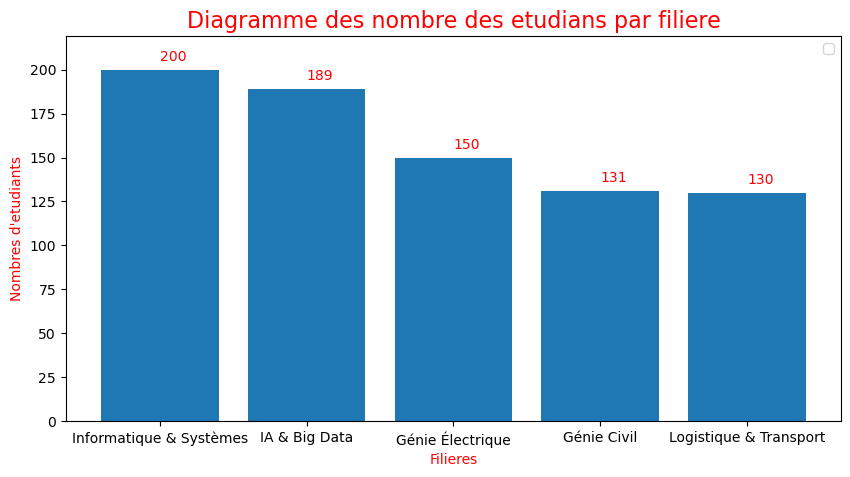

In [6]:
# Moi j'ai utiliser matplotlib pour la representation avec seaborn la syntaxe devrais :
# data["filiere"].value_counts().plot(kind = "bar")


plt.figure(figsize =(10, 5))
df_ordonne = df.sort_values("count", ascending = False)
plt.bar( height = df_ordonne["count"], x = df_ordonne["filiere"])
plt.title("Diagramme des nombre des etudians par filiere", size =16, c = "red")
plt.ylim(0, 219)
# plt.grid(axis = "y")
plt.xlabel("Filieres", size = 10, c= "red")
plt.ylabel("Nombres d'etudiants", size = 10, c ="red")

liste = df["count"].tolist()
for i in range(len(liste)):
    plt.text(i, liste[i]+5, liste[i], c="red")
    
plt.legend()

- la filiere Informatique et systemes es la filiere ayant plus de d'etudiant : ***200*** etudiants inscrits au total, et la filiere possedant le moins d'etudaint est la filiere ***Logistique & Transport*** au tolat ***130*** Etudiants inscrits

#### 3-) Les effectifs sont-ils équilibrés ?

In [7]:
proportion  = data["filiere"].value_counts(normalize = True)*(100)
proportion = round(proportion, 2).reset_index()
proportion 

,filiere,proportion
0,Informatique & Systèmes,25.00
1,IA & Big Data,23.62
2,Génie Électrique,18.75
3,Génie Civil,16.38
4,Logistique & Transport,16.25


Les effectifs sont un peut équilibrés entre les filières : chacune représente ses nombre d'etudiant plus proches du total des étudiants, 
soit une moins stricte.

#### 4-) Quelle proportion représente chaque filière ?

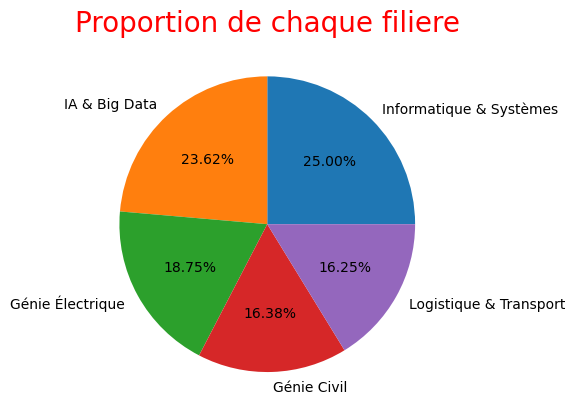

In [8]:
# Je vais tracer un diagramme circulaire pour represente la proportion de chaque filiere
plt.title("Proportion de chaque filiere", c = "red", size =20)
plt.pie( x = df["count"], labels = df["filiere"], autopct ="%.2f%%")
plt.show()

**5 - Reponse** : analyse graphique confirme belles et biens  les calcules avec pandas car les proportions on des legers ecarts

Selon moi La representation la plus lisible est le diagramme de bar , mais les deux representation sont tous visible, il faut noter que j'ai tester avec la fonction barplot , de seaborn je ne sais pas si c'est moi qui ne maitrise pas les bonnes pratiques , mais la representation n'est pas lisible.

# PARTIE 2 — RÉPARTITION PAR SEXE

### Graphiques
- Barplot.
- Représentation proportionnelle.
- Sexe par filière.

### Questions
1. Quelle catégorie est majoritaire ?
2. Quelle proportion représente-t-elle ?
3. La répartition est-elle équilibrée ?
4. La répartition varie-t-elle selon les filières ?
5. Quelle filière présente la plus grande différence ?
6. Quel graphique permet le mieux de comparer les filières ?
7. Que peux-tu conclure ?

---

#### 1-) determination de la categorie majoritaire

In [9]:
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent


In [10]:
cate = data.groupby("sexe")["sexe"].value_counts()
cate = cate.reset_index()
cate

,sexe,count
0,F,327
1,M,465
2,inconnue,8


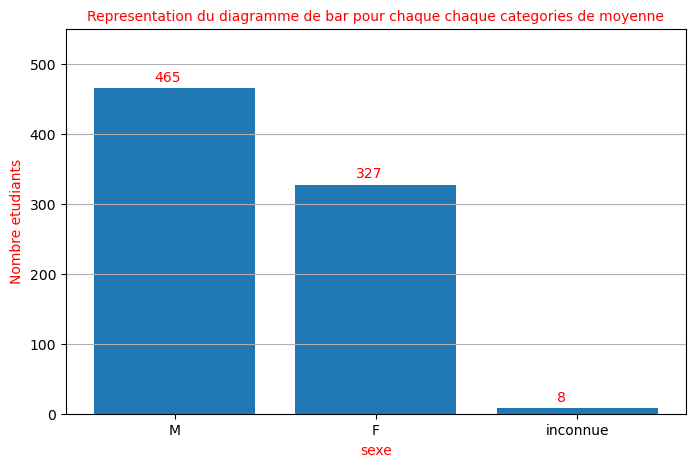

In [11]:
cate_Trier = cate.sort_values("count", ascending = False)
plt.figure(figsize =(8, 5))
plt.bar(x = cate_Trier["sexe"], height = cate_Trier["count"])
plt.xlabel("sexe", c="red") 
plt.ylabel("Nombre etudiants", c = "red")
plt.ylim(0, 550) # Limite du draphique
plt.title("Representation du diagramme de bar pour chaque chaque categories de moyenne", c = "red", size = 10)

liste = cate_Trier["count"].tolist()
for i in range(len(liste)):
    plt.text(i-0.1, liste[i]+10, liste[i], c = "red")

plt.grid(axis = "y")

 La categories Masculine est la categoire ***majoritaire*** avec ***465 etudiants***

<Axes: xlabel='sexe', ylabel='age'>

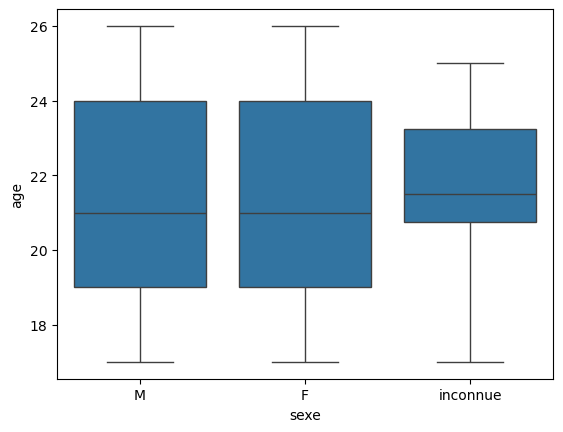

In [29]:
sns.boxplot(data = data , x ="sexe" , y = "age")

il y'a beaucoup d'etudiant avec des ages concentreer  plus de 21 ans , les ages max et nmin des sexe femini et masculin soint de 
(environ 17 ans a 26 ans ) avec des ages tres disperser beaucou p d'etudinst on des ages tre varie

#### 2- ) Quelle proportion représente-t-elle( la categorie majoritaire) ?

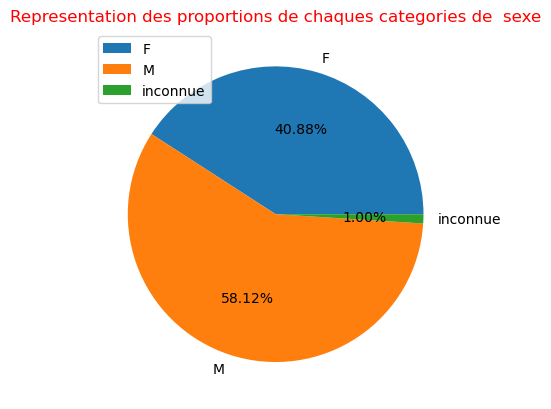

In [12]:
plt.pie(x = cate["count"], labels = cate["sexe"], autopct = "%.2f%%")
plt.title("Representation des proportions de chaques categories de  sexe", c = "red")
plt.legend()

 La repartion n'est pas equilibre car on as environ 7% d' ecart de proportion pour chaque categories de sexe et 1% de sexe non connues donc en 
definitive la repartion n'est pas equilibre

#### 3 - ) La répartition varie-t-elle selon les filières ?

In [13]:
# Pour l'instant il faut effectuer des analyses afin de le savoir ,
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent


In [14]:
# 1. Tableau des effectifs (Nombre de Hommes / Femmes par filière)
tableau_effectifs = pd.crosstab(data['filiere'], data['sexe'])
print("--- Effectifs par filière ---")
tableau_effectifs

--- Effectifs par filière ---


sexe,F,M,inconnue
filiere,,,
Génie Civil,59,71,1
Génie Électrique,63,85,2
IA & Big Data,71,115,3
Informatique & Systèmes,81,117,2
Logistique & Transport,53,77,0


In [15]:
# 2. Tableau en pourcentages par filière (Très important !)
# normalize='index' calcule le % de chaque sexe au sein de chaque filière
tableau_pourcentages = pd.crosstab(data['filiere'], data['sexe'], normalize="index") * 100
print("\n--- Pourcentages au sein de chaque filière (%) ---")
table= tableau_pourcentages.round(2)
table


--- Pourcentages au sein de chaque filière (%) ---


sexe,F,M,inconnue
filiere,,,
Génie Civil,45.04,54.20,0.76
Génie Électrique,42.00,56.67,1.33
IA & Big Data,37.57,60.85,1.59
Informatique & Systèmes,40.50,58.50,1.00
Logistique & Transport,40.77,59.23,0.00


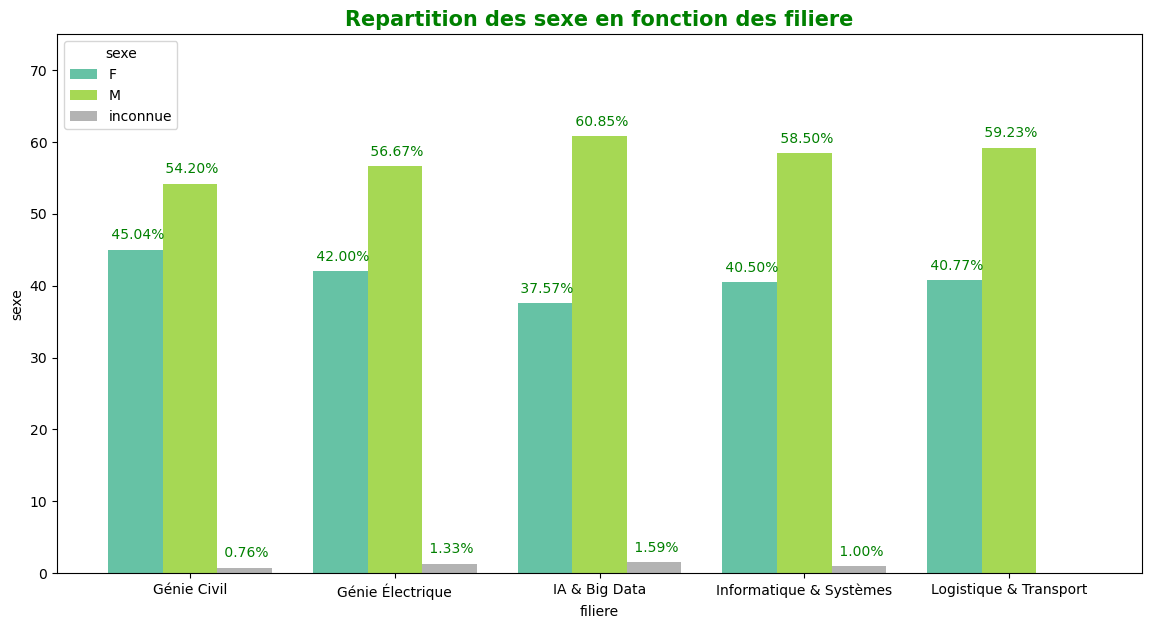

In [16]:
ax = table.plot(kind = "bar", cmap = "Set2", figsize = (14, 7), width = 0.8)
plt.title("Repartition des sexe en fonction des filiere", c= "green", fontweight = "bold", fontsize = 15)
plt.ylabel("sexe")
plt.xticks(rotation = 0)
plt.ylim(0, 75)

for container in ax.containers:
    for objet in container :
        taille = objet.get_height()
        if taille > 0:
            x = objet.get_x() + objet.get_width()/2
            y = taille + 2 # Petit decalage de 2% vers le haut
            plt.text(x, y, f"{taille : .2f}%", va = "center", ha = "center", color = "green")

#### Les categories varies en fonction des filieres

5. ) - La filiere presentant la plus  grande difference  :  ***Intellegicence Artificilelle et Bigdata (IA & BD)***

6_) - Selon moi c'est le ***diagramme de bar*** qui permet de comparer le mieux les filieres


# PARTIE 3 — DISTRIBUTION DES ÂGES

### Graphiques
- Histogramme.
- Histogramme + KDE.
- Boxplot.

### Questions
1. Quelle tranche d'âge est la plus représentée ?
2. La distribution est-elle concentrée ou dispersée ?
3. Est-elle symétrique ?
4. Existe-t-il des valeurs atypiques ?
5. Que montre le boxplot ?
6. Quel graphique représente le mieux la distribution ?
7. Quel graphique permet de détecter les valeurs atypiques ?
8. Quelle conclusion ?

---

#### 1- ) La tranche d'age la plus represente

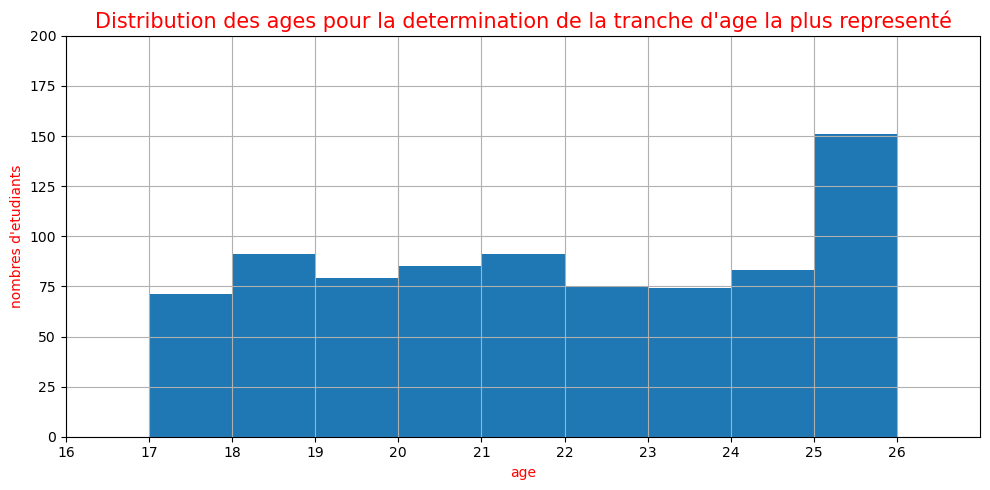

In [51]:
plt.figure(figsize = (10, 5))
plt.hist(data["age"],bins = 9)
plt.title("Distribution des ages pour la determination de la tranche d'age la plus representé", fontsize = 15 , c = "red")
plt.ylabel("nombres d'etudiants", c ="red")
plt.xlabel("age", c ="red")
#plt.yticks(ticks = np.arange(0, 100, 10))
plt.xticks(ticks = np.arange(0, 27, 1))
plt.ylim(0, 200)
plt.xlim(16, 27)
plt.tight_layout()
plt.grid()

##### La recherche de la tranche d'age la plus representer revient a determiner l'intervalle quui a la  bar le plus elevee : Dans le'histogramme.Dans notre cas cet **intervalle  est entre [25 ans , 26 ans]**

La distrubution est dispercer

#### 4-) Verification des valeurs atypique

C:\Users\dc\AppData\Local\Temp\ipykernel_33216\719717652.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x = "filiere" ,y = "age", palette = "Set2")


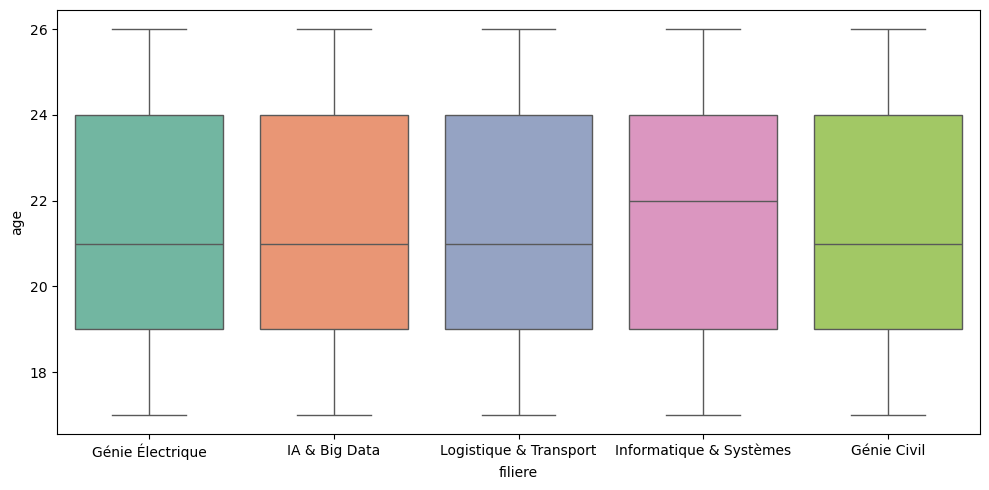

In [18]:
plt.figure(figsize = (10,5))
sns.boxplot(data = data, x = "filiere" ,y = "age", palette = "Set2")
plt.tight_layout()

# PARTIE 4 — DISTRIBUTION DES NOTES

### Graphiques
- Histogramme.
- Histogramme + KDE.
- Boxplot.

### Questions
1. Où se concentrent les notes ?
2. Quelle tranche est la plus fréquente ?
3. Les notes sont-elles plutôt faibles ou élevées ?
4. Combien de notes sont visuellement sous 10 ?
5. Existe-t-il beaucoup de notes élevées ?
6. Existe-t-il des valeurs atypiques ?
7. La distribution semble-t-elle normale ?
8. Quel graphique est le plus informatif ?
9. Le résultat confirme-t-il Pandas ?
10. Quelle conclusion sur le niveau général ?


In [19]:
data_notes = pd.read_csv("../projet_pandas_universitaire/notes.csv")
data_notes.head()

,student_id,course_id,note
0,ETU1000,MAT101,6.03
1,ETU1000,PHY101,6.54
2,ETU1000,PROG101,8.00
3,ETU1000,STAT101,10.48
4,ETU1000,ANG101,8.31


#### 1 - )  Où se concentrent les notes ?

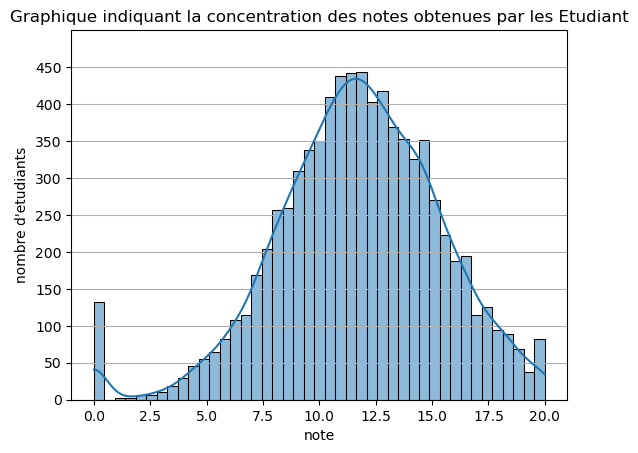

In [20]:
sns.histplot(data_notes["note"], kde = True)
plt.title("Graphique indiquant la concentration des notes obtenues par les Etudiant")
plt.ylabel("nombre d'etudiants")
plt.ylim(0, 500)
plt.yticks( ticks = np.arange(0, 500, 50))
plt.grid(axis = "y")

In [21]:
# La tranche la plus frequence : [11, 12]

#### 6- ) Valeurs atypiques

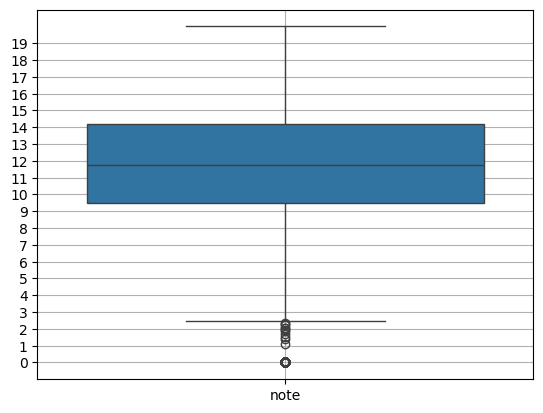

In [35]:
sns.boxplot(data = data_notes)
plt.yticks(ticks = np.arange(0, 20, 1))
plt.grid()


# PARTIE 5 RÉUSSITE ET ÉCHEC

Règle déjà utilisée dans Pandas : **note >= 10 = réussite ; note < 10 = échec**.

### Graphiques
- Barplot réussite/échec.
- Représentation proportionnelle.

### Questions
1. Quelle catégorie domine ?
2. Quel est le taux de réussite ?
3. Quel est le taux d'échec ?
4. L'écart est-il important ?
5. Le niveau paraît-il satisfaisant ?
6. Quel graphique est le plus efficace ?
7. Quelle conclusion ?

---

In [23]:
data_notes.head()

,student_id,course_id,note
0,ETU1000,MAT101,6.03
1,ETU1000,PHY101,6.54
2,ETU1000,PROG101,8.00
3,ETU1000,STAT101,10.48
4,ETU1000,ANG101,8.31


#### 1-) La categories qui domine le plue (ECHEC / REUSSITES)

In [24]:
def categorie_notes(notes):
    if notes < 10:
        return "échec"
        
    else: 
        return "réussite"
        
data_notes["categorie_notes"] = data_notes.apply(
    lambda applique_ligne: categorie_notes(applique_ligne["note"]), axis = 1)
data_notes.head()

,student_id,course_id,note,categorie_notes
0,ETU1000,MAT101,6.03,échec
1,ETU1000,PHY101,6.54,échec
2,ETU1000,PROG101,8.00,échec
3,ETU1000,STAT101,10.48,réussite
4,ETU1000,ANG101,8.31,échec


Text(0, 0.5, "Nombre d'etudiant")

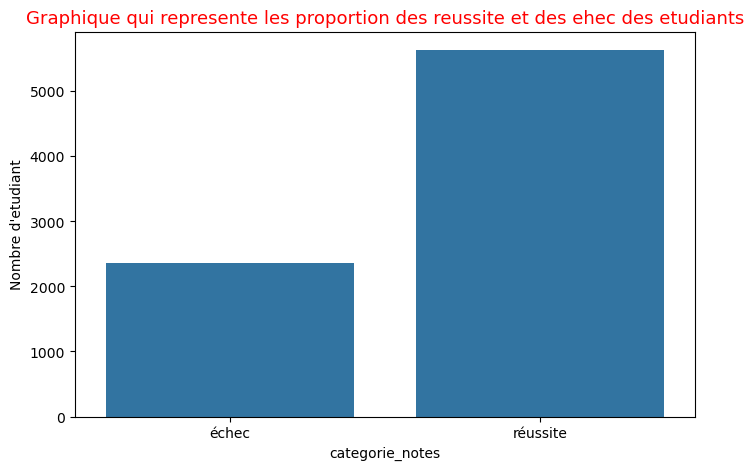

In [48]:
plt.figure(figsize = (8, 5))
sns.countplot(data = data_notes, x="categorie_notes")
plt.title("Graphique qui represente les proportion des reussite et des ehec des etudiants",  size = 13, c = "red")
plt.ylabel("Nombre d'etudiant")

La categorie qui domine le plus est la categorie des ***reussite***

#### 2 -) Quel est le taux de réussite ?

In [65]:
#Utilisont un camenbert pour repondre a cette question 


In [69]:
taux_resultat = round(data_notes["categorie_notes"].value_counts(normalize = True)*100, 2)
taux_resultat = taux_resultat.reset_index()
taux_resultat

,categorie_notes,proportion
0,réussite,70.41
1,échec,29.59


Text(0.5, 1.0, "Repartition du taux de reussite et d'echec")

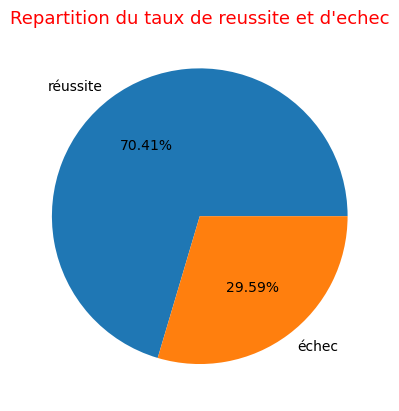

In [72]:
plt.pie(x = taux_resultat["proportion"], labels = taux_resultat["categorie_notes"], autopct = "%.2f%%")
plt.title("Repartition du taux de reussite et d'echec", c = "red", size = "13")

Oui l'ecart est vraiment important 


# PARTIE 6 — MOYENNE PAR FILIÈRE

### Graphiques
- Barplot.
- Classement graphique.

### Questions
1. Quelle filière possède la meilleure moyenne ?
2. Quelle possède la plus faible ?
3. Quelle est la différence entre les deux ?
4. Les écarts sont-ils importants ?
5. Combien de filières ont une moyenne >= 10 ?
6. Le graphique confirme-t-il Pandas ?
7. Quelle filière semble la plus performante ?
8. Laquelle nécessite davantage d'attention ?


In [73]:
data.head()

,student_id,nom,prenom,age,sexe,filiere,niveau,moyenne_Generale,Categorie
0,ETU1648,Assogba,Mawuli,18,M,Génie Électrique,L1,18.64,Excellent
1,ETU1416,Assogba,Afi,21,M,IA & Big Data,L1,18.48,Excellent
2,ETU1060,Assogba,Dodzi,23,M,Logistique & Transport,L1,18.23,Excellent
3,ETU1050,Agbeko,Dodzi,18,M,Logistique & Transport,L1,18.14,Excellent
4,ETU1784,Amegan,Sena,21,F,IA & Big Data,L3,18.12,Excellent


#### 1- Quelle filière possède la meilleure moyenne ?